# Paper-Feature LSTM Volatility Filter + EVT

Paper-inspired OHLCV feature LSTM with the same EVT evaluation pipeline.


In [1]:
import math, random, warnings
from copy import deepcopy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import genpareto, jarque_bera, chi2, norm
from statsmodels.stats.diagnostic import acorr_ljungbox

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    HAS_TORCH=True
except ImportError:
    HAS_TORCH=False
if not HAS_TORCH:
    raise ImportError('torch is unavailable. Stopping as requested; no substitute architecture will be used.')

warnings.filterwarnings('ignore', category=RuntimeWarning)
sns.set(style='whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
SEEDS=[0,1,2,3,4]
WINDOW=30
HIDDEN_SIZE=20
DENSE_SIZE=10
DROPOUT=0.10
BATCH_SIZE=64
TRAIN_END=pd.Timestamp('2018-01-01')
NU_FIXED=5.763
TAIL_Q=0.064
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'torch {torch.__version__}, device={DEVICE}')
print(f'Seeds: {SEEDS}')
print(f'Paper-inspired fixed architecture: window={WINDOW}, LSTM hidden={HIDDEN_SIZE}, dense={DENSE_SIZE}, dropout={DROPOUT}, batch={BATCH_SIZE}')


torch 2.6.0, device=cpu
Seeds: [0, 1, 2, 3, 4]
Paper-inspired fixed architecture: window=30, LSTM hidden=20, dense=10, dropout=0.1, batch=64


## Shared EVT Helpers

GPD and VaR helpers match the earlier notebooks.


In [2]:
def gpd_neg_log_pdf(y, xi, sigma, eps=1e-9):
    y=np.asarray(y,dtype=float); sigma=np.asarray(sigma,dtype=float)
    z=xi*y/sigma; one_plus_z=np.clip(1.0+z,eps,None)
    return np.log(sigma)+(1.0+1.0/xi)*np.log(one_plus_z)

def gpd_var(u, xi, beta, q_u, p):
    if (1-p)>q_u:
        raise ValueError(f'VaR at p={p} needs tail probability {1-p:.4f}, exceeding q_u={q_u:.4f}')
    return u-(beta/xi)*(((1-q_u)/(1-p))**xi-1)

def devolatilized_var(z_q, mu_hat, sigma_hat):
    return mu_hat+sigma_hat*z_q

def gpd_xi_ci(xi_hat,n_exc,z=1.96):
    se=(1+xi_hat)/np.sqrt(n_exc)
    return xi_hat-z*se, xi_hat+z*se, se

def kupiec_pof_test(violations, alpha):
    v=np.asarray(violations,dtype=int); n=len(v); x=int(v.sum()); ph=np.clip(x/n,1e-12,1-1e-12)
    ll0=(n-x)*np.log(1-alpha)+x*np.log(alpha); ll1=(n-x)*np.log(1-ph)+x*np.log(ph)
    lr=-2*(ll0-ll1); return lr,1-chi2.cdf(lr,1)

def christoffersen_independence_test(violations):
    v=np.asarray(violations,dtype=int); prev,curr=v[:-1],v[1:]
    n00=int(((prev==0)&(curr==0)).sum()); n01=int(((prev==0)&(curr==1)).sum())
    n10=int(((prev==1)&(curr==0)).sum()); n11=int(((prev==1)&(curr==1)).sum())
    def term(n,p): return 0.0 if n==0 else n*np.log(np.clip(p,1e-12,1-1e-12))
    pi=(n01+n11)/max(n00+n01+n10+n11,1); pi0=n01/max(n00+n01,1); pi1=n11/max(n10+n11,1)
    ll0=term(n00+n10,1-pi)+term(n01+n11,pi)
    ll1=term(n00,1-pi0)+term(n01,pi0)+term(n10,1-pi1)+term(n11,pi1)
    lr=-2*(ll0-ll1); return lr,1-chi2.cdf(lr,1)

def fmt(vals,digits=4):
    a=np.asarray(vals,dtype=float); sd=np.nanstd(a,ddof=1) if np.isfinite(a).sum()>1 else 0.0
    return f'{np.nanmean(a):.{digits}f} +/- {sd:.{digits}f}'

_y=np.array([0.1,0.5,1.0,2.0,5.0])
assert np.allclose(-genpareto.logpdf(_y,c=0.15,loc=0,scale=0.6), gpd_neg_log_pdf(_y,0.15,0.6))
print('GPD helper verified against scipy.stats.genpareto.')


GPD helper verified against scipy.stats.genpareto.


## Features

Inputs include returns, volume change, high-low range, absolute/squared returns, and lagged realized volatility.


In [3]:
spy=pd.read_csv('spy.csv')
cols={x.lower():x for x in spy.columns}
df=spy[[cols['date'],cols['open'],cols['high'],cols['low'],cols['close'],cols['volume']]].copy()
df.columns=['Date','Open','High','Low','Close','Volume']
df['Date']=pd.to_datetime(df['Date']); df=df.sort_values('Date').reset_index(drop=True)
df['Return']=100*np.log(df['Close']/df['Close'].shift(1))
df['LogVolumeChange']=np.log(df['Volume'].replace(0,np.nan)/df['Volume'].replace(0,np.nan).shift(1))
df['LogRange']=100*np.log(df['High']/df['Low'])
df['AbsReturn']=df['Return'].abs()
df['SquaredReturn']=df['Return']**2
df['RV10_prev']=df['Return'].rolling(10).std().shift(1)
df['RV30_prev']=df['Return'].rolling(30).std().shift(1)
std=pd.read_csv('standardized_residuals.csv'); std['Date']=pd.to_datetime(std['Date'])
gp=pd.read_csv('garch_params.csv').iloc[0]
mu_pct=float(gp['Mu'])*100; nu_garch=float(gp['Nu'])
df=df.merge(std[['Date','t Standardized Residuals','Conditional Volatility']],on='Date',how='left')
df['GARCH Sigma']=df['Conditional Volatility']*100
features=['Return','LogVolumeChange','LogRange','AbsReturn','SquaredReturn','RV10_prev','RV30_prev']
model_df=df.dropna(subset=features+['Return']).reset_index(drop=True)
model_df['Train']=model_df['Date']<TRAIN_END
print(f'Rows after feature warmup: {len(model_df):,}; train={model_df.Train.sum():,}; test={(~model_df.Train).sum():,}')
print(f'GARCH mu percent units: {mu_pct:.6f}; fixed LSTM nu={NU_FIXED:.3f}')
model_df[['Date']+features].head()


Rows after feature warmup: 10,121; train=8,288; test=1,833
GARCH mu percent units: 0.076445; fixed LSTM nu=5.763


,Date,Return,LogVolumeChange,LogRange,AbsReturn,SquaredReturn,RV10_prev,RV30_prev
0,1985-02-14,-0.5140,-0.0198,0.8517,0.5140,0.2642,0.7182,0.7521
1,1985-02-15,-0.4450,-0.2714,0.7805,0.4450,0.1981,0.7549,0.7532
2,1985-02-19,-0.1488,-0.1639,0.3641,0.1488,0.0221,0.7439,0.7495
3,1985-02-20,-0.0828,0.2681,0.8050,0.0828,0.0068,0.6933,0.7549
4,1985-02-21,-0.5479,-0.1280,0.6423,0.5479,0.3002,0.6938,0.7535


In [4]:
def make_feature_sequences(frame, features, window=WINDOW):
    Xv=frame[features].to_numpy(dtype=np.float32); r=frame['Return'].to_numpy(dtype=np.float32)
    X=[]; y=[]; idx=[]
    for i in range(window,len(frame)):
        X.append(Xv[i-window:i]); y.append(r[i]); idx.append(i)
    return np.asarray(X,dtype=np.float32), np.asarray(y,dtype=np.float32), np.asarray(idx,dtype=int)
X_raw,y_all,seq_idx=make_feature_sequences(model_df,features,WINDOW)
seq_dates=model_df.loc[seq_idx,'Date'].reset_index(drop=True)
train_seq=(seq_dates<TRAIN_END).to_numpy(); test_seq=~train_seq
train_pos=np.flatnonzero(train_seq); n_fit=int(np.floor(0.85*len(train_pos)))
fit_mask=np.zeros_like(train_seq,dtype=bool); val_mask=np.zeros_like(train_seq,dtype=bool)
fit_mask[train_pos[:n_fit]]=True; val_mask[train_pos[n_fit:]]=True
x_mean=X_raw[fit_mask].mean(axis=(0,1),keepdims=True); x_std=X_raw[fit_mask].std(axis=(0,1),keepdims=True)
x_std=np.where(x_std<1e-8,1.0,x_std)
X_all=(X_raw-x_mean)/x_std
print(f'Sequence fit/val/test: {fit_mask.sum():,} / {val_mask.sum():,} / {test_seq.sum():,}')
print(f"First target date {seq_dates.iloc[0].date()} uses window ending {model_df.loc[seq_idx[0]-1,'Date'].date()}")
print(pd.Series(x_mean.ravel(), index=features).to_frame('fit mean').join(pd.Series(x_std.ravel(), index=features).to_frame('fit std')))


Sequence fit/val/test: 7,019 / 1,239 / 1,833
First target date 1985-03-29 uses window ending 1985-03-28
                 fit mean  fit std
Return             0.0298   1.1856
LogVolumeChange    0.0005   0.2063
LogRange           1.3112   0.9848
AbsReturn          0.7809   0.8927
SquaredReturn      1.4067   7.6325
RV10_prev          0.9899   0.6772
RV30_prev          1.0161   0.6205


## Feature LSTM

30-day feature window, 20 LSTM units, 10-unit dense layer, 10% dropout.


In [5]:
class FeatureLSTMVol(nn.Module):
    def __init__(self, n_features, hidden=HIDDEN_SIZE, dense=DENSE_SIZE, dropout=DROPOUT, log_sigma_init=0.0):
        super().__init__()
        self.lstm=nn.LSTM(n_features, hidden, num_layers=1, batch_first=True)
        self.drop1=nn.Dropout(dropout)
        self.fc=nn.Linear(hidden,dense)
        self.drop2=nn.Dropout(dropout)
        self.head=nn.Linear(dense,1)
        nn.init.zeros_(self.head.weight)
        with torch.no_grad(): self.head.bias.fill_(float(log_sigma_init))
    def forward(self,x):
        out,_=self.lstm(x)
        h=self.drop1(out[:,-1,:])
        h=torch.relu(self.fc(h))
        h=self.drop2(h)
        return torch.clamp(self.head(h).squeeze(-1), min=-8.0, max=4.0)

def student_t_unitvar_nll(y,mu,log_sigma,nu):
    sigma=torch.exp(log_sigma); z=(y-mu)/sigma; scale=torch.sqrt((nu-2)/nu); t=z/scale
    log_pdf=torch.lgamma((nu+1)/2)-torch.lgamma(nu/2)-0.5*(torch.log(nu)+math.log(math.pi))
    log_pdf=log_pdf-((nu+1)/2)*torch.log1p((t*t)/nu)-torch.log(scale)
    return torch.log(sigma)-log_pdf

def set_seeds(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

def count_params(model): return int(sum(p.numel() for p in model.parameters() if p.requires_grad))

def fit_feature_lstm(seed, max_epochs=350, patience=35):
    set_seeds(seed)
    model=FeatureLSTMVol(len(features), log_sigma_init=float(np.log(np.std(y_all[fit_mask]-mu_pct)))).to(DEVICE)
    opt=torch.optim.Adam(model.parameters(), lr=1e-3)
    Xf=torch.tensor(X_all[fit_mask],device=DEVICE); yf=torch.tensor(y_all[fit_mask],device=DEVICE)
    Xv=torch.tensor(X_all[val_mask],device=DEVICE); yv=torch.tensor(y_all[val_mask],device=DEVICE)
    ds=TensorDataset(Xf,yf)
    gen=torch.Generator(device='cpu'); gen.manual_seed(seed)
    loader=DataLoader(ds,batch_size=BATCH_SIZE,shuffle=True,generator=gen)
    mu=torch.tensor(mu_pct,dtype=torch.float32,device=DEVICE); nu=torch.tensor(NU_FIXED,dtype=torch.float32,device=DEVICE)
    best=None; best_val=np.inf; best_epoch=-1; bad=0
    for epoch in range(max_epochs):
        model.train(); losses=[]
        for xb,yb in loader:
            opt.zero_grad(); loss=student_t_unitvar_nll(yb,mu,model(xb),nu).mean(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),5.0); opt.step(); losses.append(float(loss.detach().cpu()))
        model.eval()
        with torch.no_grad(): val=student_t_unitvar_nll(yv,mu,model(Xv),nu).mean().item()
        if val < best_val-1e-5:
            best_val=val; best_epoch=epoch; best=deepcopy(model.state_dict()); bad=0
        else:
            bad+=1
        if bad>=patience: break
    model.load_state_dict(best); model.eval()
    with torch.no_grad(): sig_seq=torch.exp(model(torch.tensor(X_all,device=DEVICE))).cpu().numpy()
    sigma=np.full(len(model_df),np.nan); sigma[seq_idx]=sig_seq
    return {'seed':seed,'model':model,'sigma_full':sigma,'best_val_nll':best_val,'best_epoch':best_epoch,'epochs_run':epoch+1,'param_count':count_params(model)}


## Training and No-Lookahead Check


In [6]:
feature_results=[]
for seed in SEEDS:
    r=fit_feature_lstm(seed)
    feature_results.append(r)
    print(f"seed={seed}: val NLL={r['best_val_nll']:.4f}, best_epoch={r['best_epoch']}, epochs_run={r['epochs_run']}")
print(f"Feature LSTM parameter count: {feature_results[0]['param_count']:,}")


seed=0: val NLL=0.9851, best_epoch=20, epochs_run=56


seed=1: val NLL=0.9810, best_epoch=43, epochs_run=79


seed=2: val NLL=0.9822, best_epoch=51, epochs_run=87


seed=3: val NLL=0.9821, best_epoch=39, epochs_run=75


seed=4: val NLL=0.9829, best_epoch=52, epochs_run=88
Feature LSTM parameter count: 2,541


In [7]:
def build_features_from_returns(raw_returns):
    tmp=pd.DataFrame({'Return':np.asarray(raw_returns,dtype=float)})
    tmp['LogVolumeChange']=0.0
    tmp['LogRange']=np.abs(tmp['Return'])*0.25
    tmp['AbsReturn']=tmp['Return'].abs()
    tmp['SquaredReturn']=tmp['Return']**2
    tmp['RV10_prev']=tmp['Return'].rolling(10).std().shift(1).fillna(0.0)
    tmp['RV30_prev']=tmp['Return'].rolling(30).std().shift(1).fillna(0.0)
    return tmp[features].to_numpy(dtype=np.float32)

def predict_sigma_synthetic(model, raw_returns):
    F=build_features_from_returns(raw_returns); X=[]; idx=[]
    for i in range(WINDOW,len(F)):
        X.append(F[i-WINDOW:i]); idx.append(i)
    X=np.asarray(X,dtype=np.float32); X=(X-x_mean)/x_std
    model.eval()
    with torch.no_grad(): sig=torch.exp(model(torch.tensor(X,dtype=torch.float32,device=DEVICE))).cpu().numpy()
    out=np.full(len(raw_returns),np.nan); out[np.asarray(idx)]=sig; return out

def no_lookahead_check(model,k=60,shock=-25.0):
    quiet=np.zeros(120,dtype=np.float32); shocked=quiet.copy(); shocked[k]=shock
    sq=predict_sigma_synthetic(model,quiet); ss=predict_sigma_synthetic(model,shocked); d=np.abs(ss-sq)
    before=np.nanmax(d[WINDOW:k+1]); after=np.nanmax(d[k+1:k+WINDOW+1])
    passed=bool(np.isfinite(d[k]) and d[k]<1e-8 and before<1e-8 and after>1e-8)
    print(f"No-lookahead check at shock index k={k}: {'PASS' if passed else 'FAIL'}")
    print(f"  |sigma_shocked[k] - sigma_quiet[k]| = {d[k]:.12f}")
    print(f"  max pre/current difference through k = {before:.12f}")
    print(f"  max post-shock difference k+1..k+30 = {after:.12f}")
    return passed
if not no_lookahead_check(feature_results[0]['model']):
    raise RuntimeError('No-lookahead test failed; stopping before EVT pipeline.')


No-lookahead check at shock index k=60: PASS
  |sigma_shocked[k] - sigma_quiet[k]| = 0.000000000000
  max pre/current difference through k = 0.000000000000
  max post-shock difference k+1..k+30 = 1.600479662418


## EVT Evaluation


In [8]:
def evaluate_arm(name,z_full,sigma_full,param_count,seed=None,nu=NU_FIXED):
    d=model_df.copy(); d['z']=z_full; d['sigma']=sigma_full
    valid=d['z'].notna()&d['sigma'].notna(); train=valid&(d['Date']<TRAIN_END); test=valid&(d['Date']>=TRAIN_END)
    ztr=d.loc[train,'z'].to_numpy(); zte=d.loc[test,'z'].to_numpy(); rte=d.loc[test,'Return'].to_numpy(); ste=d.loc[test,'sigma'].to_numpy()
    u=float(np.quantile(ztr,TAIL_Q)); exc=u-ztr[ztr<u]; texc=u-zte[zte<u]
    xi,loc,beta=genpareto.fit(exc,floc=0); assert loc==0
    q_u=len(exc)/len(ztr); _,_,xise=gpd_xi_ci(xi,len(exc)); z95=gpd_var(u,xi,beta,q_u,0.95); z99=gpd_var(u,xi,beta,q_u,0.99)
    var95=devolatilized_var(z95,mu_pct,ste); var99=devolatilized_var(z99,mu_pct,ste)
    v95=rte<var95; v99=rte<var99; _,kp=kupiec_pof_test(v99,0.01); _,cp=christoffersen_independence_test(v99)
    lb=acorr_ljungbox(zte**2,lags=[10,22],return_df=True); jb=jarque_bera(zte)
    return {'arm':name,'seed':seed,'nu':nu,'n_train':len(ztr),'n_test':len(zte),'param_count':param_count,'u':u,'train_exceed':len(exc),'test_exceed':len(texc),'xi':float(xi),'xi_se':float(xise),'gpd_sigma':float(beta),'z_95':z95,'z_99':z99,'lb_sq_p_lag10':float(lb.loc[10,'lb_pvalue']),'lb_sq_p_lag22':float(lb.loc[22,'lb_pvalue']),'excess_kurtosis':float(pd.Series(zte).kurt()),'jb_stat':float(jb.statistic),'jb_pvalue':float(jb.pvalue),'kupiec99_pvalue':float(kp),'christoffersen99_pvalue':float(cp),'viol95_obs':int(v95.sum()),'viol95_exp':0.05*len(v95),'viol99_obs':int(v99.sum()),'viol99_exp':0.01*len(v99),'conditional_var99_mean':float(np.mean(var99)),'unconditional_var99':float(devolatilized_var(z99,mu_pct,np.nanmean(d.loc[train,'sigma']))),'viol99_seq':v99.astype(int),'z_test':zte}

garch_metrics=evaluate_arm('GARCH(1,1)-t', model_df['t Standardized Residuals'].to_numpy(), model_df['GARCH Sigma'].to_numpy(), 7, 'baseline', nu_garch)
feature_metrics=[evaluate_arm('Paper feature LSTM-t',(model_df['Return'].to_numpy()-mu_pct)/r['sigma_full'],r['sigma_full'],r['param_count'],r['seed']) for r in feature_results]
for m in feature_metrics:
    print(f"feature LSTM seed {m['seed']}: u={m['u']:.4f}, train={m['train_exceed']}, test={m['test_exceed']}, LB22={m['lb_sq_p_lag22']:.4f}, viol99={m['viol99_obs']}")


feature LSTM seed 0: u=-1.5514, train=529, test=147, LB22=0.0000, viol99=4
feature LSTM seed 1: u=-1.5560, train=529, test=153, LB22=0.0027, viol99=4
feature LSTM seed 2: u=-1.5208, train=529, test=147, LB22=0.0007, viol99=4
feature LSTM seed 3: u=-1.5468, train=529, test=163, LB22=0.0000, viol99=6
feature LSTM seed 4: u=-1.5337, train=529, test=152, LB22=0.0000, viol99=9


In [9]:
def aggregate(ms):
    keys=['param_count','n_train','n_test','nu','u','train_exceed','test_exceed','lb_sq_p_lag10','lb_sq_p_lag22','excess_kurtosis','jb_stat','jb_pvalue','xi','xi_se','gpd_sigma','kupiec99_pvalue','christoffersen99_pvalue','viol95_obs','viol99_obs','conditional_var99_mean','unconditional_var99']
    out={k:fmt([m[k] for m in ms], 1 if k in {'param_count','n_train','n_test'} else 4) for k in keys}
    out['viol95_expected']=fmt([m['viol95_exp'] for m in ms],2); out['viol99_expected']=fmt([m['viol99_exp'] for m in ms],2)
    return out
comparison=pd.DataFrame.from_dict({'GARCH(1,1)-t':aggregate([garch_metrics]),'Paper feature LSTM-t fixed nu (5 seeds)':aggregate(feature_metrics)}, orient='index')
comparison=comparison[['param_count','n_train','n_test','nu','u','train_exceed','test_exceed','lb_sq_p_lag10','lb_sq_p_lag22','excess_kurtosis','jb_stat','jb_pvalue','xi','xi_se','gpd_sigma','kupiec99_pvalue','christoffersen99_pvalue','viol95_obs','viol95_expected','viol99_obs','viol99_expected','conditional_var99_mean','unconditional_var99']]
comparison


,param_count,n_train,n_test,nu,u,train_exceed,test_exceed,lb_sq_p_lag10,lb_sq_p_lag22,excess_kurtosis,...,xi_se,gpd_sigma,kupiec99_pvalue,christoffersen99_pvalue,viol95_obs,viol95_expected,viol99_obs,viol99_expected,conditional_var99_mean,unconditional_var99
"GARCH(1,1)-t",7.0 +/- 0.0,8288.0 +/- 0.0,1833.0 +/- 0.0,5.7633 +/- 0.0000,-1.5448 +/- 0.0000,531.0000 +/- 0.0000,130.0000 +/- 0.0000,0.0021 +/- 0.0000,0.0686 +/- 0.0000,2.5803 +/- 0.0000,...,0.0500 +/- 0.0000,0.5829 +/- 0.0000,0.0000 +/- 0.0000,0.9736 +/- 0.0000,10.0000 +/- 0.0000,91.65 +/- 0.00,1.0000 +/- 0.0000,18.33 +/- 0.00,-5.7608 +/- 0.0000,-5.3153 +/- 0.0000
Paper feature LSTM-t fixed nu (5 seeds),2541.0 +/- 0.0,8258.0 +/- 0.0,1833.0 +/- 0.0,5.7630 +/- 0.0000,-1.5417 +/- 0.0144,529.0000 +/- 0.0000,152.4000 +/- 6.5422,0.0000 +/- 0.0000,0.0007 +/- 0.0012,8.5552 +/- 10.7220,...,0.0516 +/- 0.0006,0.5173 +/- 0.0232,0.0032 +/- 0.0067,0.8585 +/- 0.0566,19.6000 +/- 3.3615,91.65 +/- 0.00,5.4000 +/- 2.1909,18.33 +/- 0.00,-4.9922 +/- 0.0797,-5.0871 +/- 0.1476


## Visual Diagnostics


Best feature LSTM seed for plots: 1 (val NLL=0.9810)


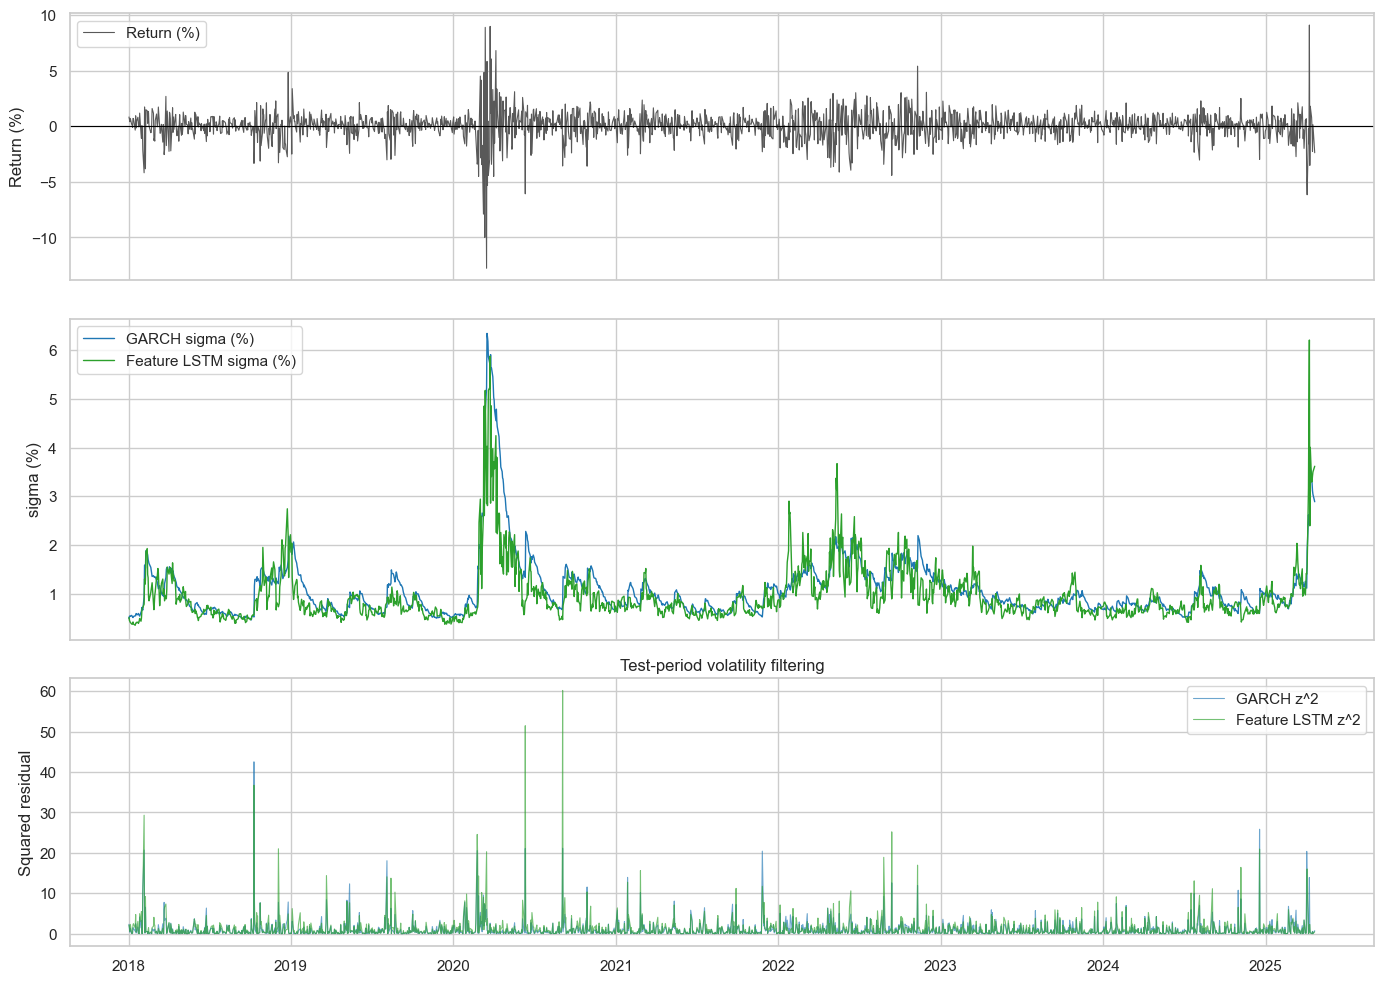

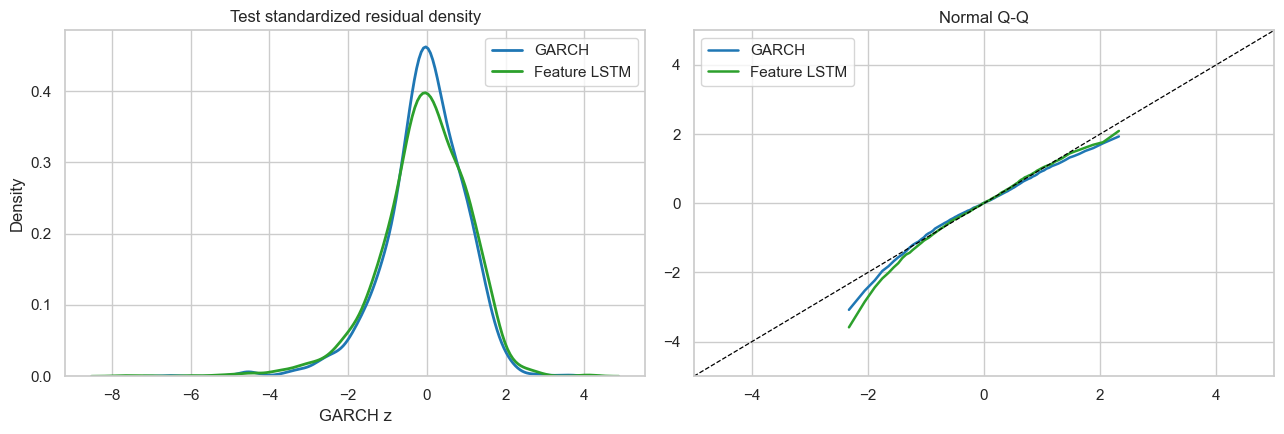

In [10]:
best=min(feature_results,key=lambda r:r['best_val_nll']); best_m=next(m for m in feature_metrics if m['seed']==best['seed'])
plot_df=model_df.copy(); plot_df['Feature Sigma']=best['sigma_full']; plot_df['Feature z']=(plot_df['Return']-mu_pct)/plot_df['Feature Sigma']; plot_df['GARCH z']=plot_df['t Standardized Residuals']
test=plot_df[plot_df['Date']>=TRAIN_END].copy()
print(f"Best feature LSTM seed for plots: {best['seed']} (val NLL={best['best_val_nll']:.4f})")
fig,axes=plt.subplots(3,1,figsize=(14,10),sharex=True,gridspec_kw={'height_ratios':[1,1.2,1]})
axes[0].plot(test['Date'],test['Return'],color='0.35',lw=0.8,label='Return (%)'); axes[0].axhline(0,color='black',lw=0.8); axes[0].legend(); axes[0].set_ylabel('Return (%)')
axes[1].plot(test['Date'],test['GARCH Sigma'],label='GARCH sigma (%)',color='tab:blue',lw=1); axes[1].plot(test['Date'],test['Feature Sigma'],label='Feature LSTM sigma (%)',color='tab:green',lw=1); axes[1].legend(); axes[1].set_ylabel('sigma (%)')
axes[2].plot(test['Date'],test['GARCH z']**2,label='GARCH z^2',color='tab:blue',alpha=.65,lw=.8); axes[2].plot(test['Date'],test['Feature z']**2,label='Feature LSTM z^2',color='tab:green',alpha=.65,lw=.8); axes[2].legend(); axes[2].set_ylabel('Squared residual')
axes[2].set_title('Test-period volatility filtering')
plt.tight_layout(); plt.show()
fig,axes=plt.subplots(1,2,figsize=(13,4.5))
for z,label,color in [(test['GARCH z'].dropna(),'GARCH','tab:blue'),(test['Feature z'].dropna(),'Feature LSTM','tab:green')]:
    sns.kdeplot(z,ax=axes[0],label=label,color=color,lw=2)
    p=np.linspace(.01,.99,99); axes[1].plot(norm.ppf(p),np.quantile(z,p),label=label,color=color,lw=1.8)
axes[0].set_title('Test standardized residual density'); axes[0].legend(); axes[1].plot([-5,5],[-5,5],color='black',ls='--',lw=.9); axes[1].set_xlim([-5,5]); axes[1].set_ylim([-5,5]); axes[1].set_title('Normal Q-Q'); axes[1].legend(); plt.tight_layout(); plt.show()


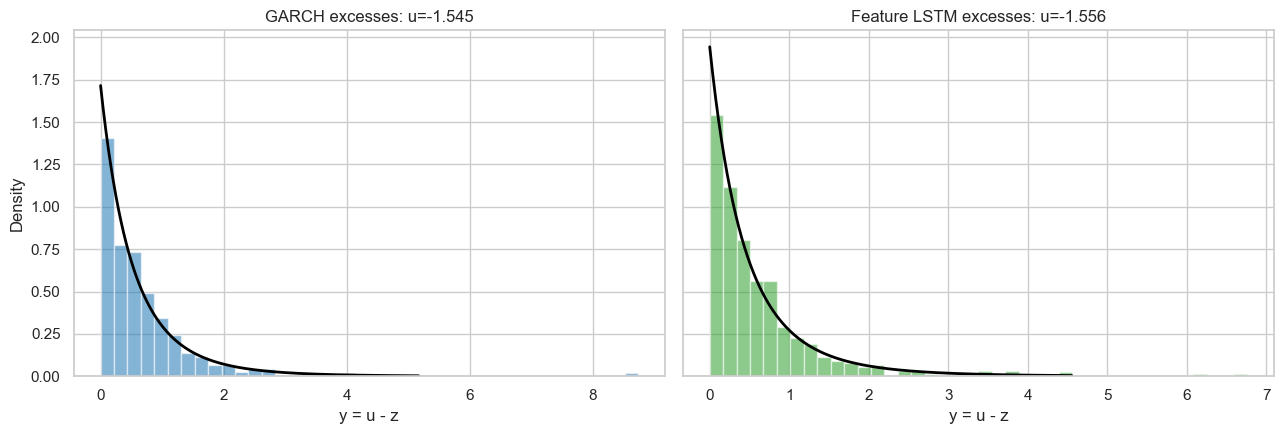

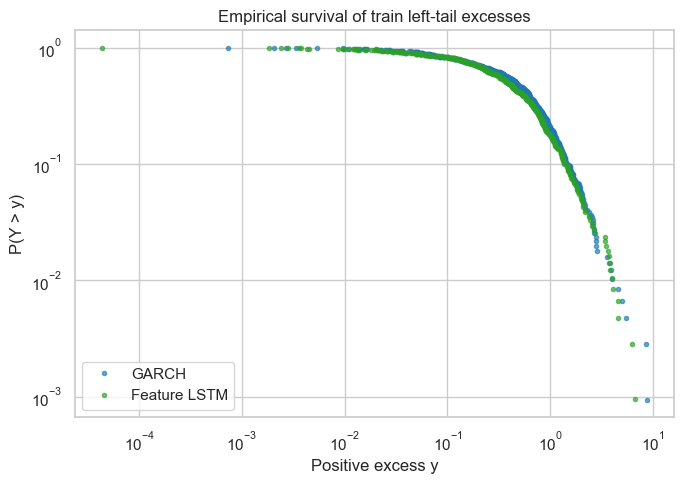

Headline comparison table:
                                            param_count         n_train          n_test                 nu                   u         train_exceed          test_exceed      lb_sq_p_lag10      lb_sq_p_lag22     excess_kurtosis                    jb_stat          jb_pvalue                 xi              xi_se          gpd_sigma    kupiec99_pvalue christoffersen99_pvalue          viol95_obs viol95_expected         viol99_obs viol99_expected conditional_var99_mean unconditional_var99
GARCH(1,1)-t                                7.0 +/- 0.0  8288.0 +/- 0.0  1833.0 +/- 0.0  5.7633 +/- 0.0000  -1.5448 +/- 0.0000  531.0000 +/- 0.0000  130.0000 +/- 0.0000  0.0021 +/- 0.0000  0.0686 +/- 0.0000   2.5803 +/- 0.0000        711.6359 +/- 0.0000  0.0000 +/- 0.0000  0.1525 +/- 0.0000  0.0500 +/- 0.0000  0.5829 +/- 0.0000  0.0000 +/- 0.0000       0.9736 +/- 0.0000  10.0000 +/- 0.0000  91.65 +/- 0.00  1.0000 +/- 0.0000  18.33 +/- 0.00     -5.7608 +/- 0.0000  -5.3153 +/- 0.0000

In [11]:
def tail_plot(metric,z):
    z=np.asarray(z,dtype=float); z=z[np.isfinite(z)]; u=metric['u']; exc=u-z[z<u]; x=np.linspace(0,np.quantile(exc,.995),250); pdf=genpareto.pdf(x,c=metric['xi'],loc=0,scale=metric['gpd_sigma']); return exc,x,pdf,u
g_exc,gx,gpdf,gu=tail_plot(garch_metrics,plot_df.loc[plot_df['Date']<TRAIN_END,'GARCH z'])
f_exc,fx,fpdf,fu=tail_plot(best_m,plot_df.loc[plot_df['Date']<TRAIN_END,'Feature z'])
fig,axes=plt.subplots(1,2,figsize=(13,4.5),sharey=True)
axes[0].hist(g_exc,bins=40,density=True,alpha=.55,color='tab:blue'); axes[0].plot(gx,gpdf,color='black',lw=2); axes[0].set_title(f'GARCH excesses: u={gu:.3f}'); axes[0].set_xlabel('y = u - z'); axes[0].set_ylabel('Density')
axes[1].hist(f_exc,bins=40,density=True,alpha=.55,color='tab:green'); axes[1].plot(fx,fpdf,color='black',lw=2); axes[1].set_title(f'Feature LSTM excesses: u={fu:.3f}'); axes[1].set_xlabel('y = u - z')
plt.tight_layout(); plt.show()
fig,ax=plt.subplots(figsize=(7,5))
for exc,label,color in [(g_exc,'GARCH','tab:blue'),(f_exc,'Feature LSTM','tab:green')]:
    s=np.sort(exc); surv=1-(np.arange(1,len(s)+1)-.5)/len(s); ax.loglog(s,surv,marker='.',ls='none',alpha=.65,color=color,label=label)
ax.set_title('Empirical survival of train left-tail excesses'); ax.set_xlabel('Positive excess y'); ax.set_ylabel('P(Y > y)'); ax.legend(); plt.tight_layout(); plt.show()
print('Headline comparison table:')
print(comparison.to_string())


## Result

The feature LSTM improves validation likelihood but does not improve residual whitening for the EVT pipeline.
